# BLS signal: Green functions, focal fields (GF#1)
This example shows how SpinWaveToolkit (SWT) can be used to calculate the expected BLS signal of a single magnetic layer using the Green's function formalism and laser electric fields in real space.

Source publication: Wojewoda et al., *Physical Review B* **110**, 224428 (2024). DOI: [10.1103/PhysRevB.110.224428](https://doi.org/10.1103/PhysRevB.110.224428)

Related examples: [GF#2](BLS_signal_from_GF_pupil.ipynb) (Green functions, pupil fields), [RT#1](BLS_signal_from_RT_focal.ipynb) (reciprocity theorem, focal fields), [RT#2](BLS_signal_from_RT_pupil.ipynb) (reciprocity theorem, pupil fields), [comparison of all methods](BLS_signal_comparison.ipynb).

We start by importing the modules we need and by defining the parameters of the system and model.

In [1]:
# Import modules
import numpy as np
import SpinWaveToolkit as SWT
from matplotlib import pyplot as plt

In [2]:
# Define parameters
Bext = 50e-3         # External field [T]
theta = np.pi / 2    # Out-of-plane angle (fixed)
phi0 = np.pi / 2     # In-plane angle of magnetization wrt. x axis
d_layer = 30e-9      # Magnetic layer thickness [m]
material = SWT.NiFe  # Material (from built-ins)
Nf_common = 101       # Number of frequency points for Bloch function

NA = 0.75            # Numerical Aperture (NA) for the lens

# Define the Kx,Ky grid limits and resolution.  The grid must be symmetric and
# equidistant, preferably with an odd number of points (k = 0 on the grid), and
# should reach 2*k0*NA (here 17.7 rad/um), since magnons with such wavevectors
# can still scatter light into the objective.
Nk = 101             # resolution in Kx and Ky
k_max = 18e6         # maximum k (rad/m)

# Create a regular Kx,Ky grid
kx_grid = np.linspace(-k_max, k_max, Nk)
ky_grid = np.linspace(-k_max, k_max, Nk)
KX, KY = np.meshgrid(kx_grid, ky_grid, indexing='ij')
K = np.sqrt(KX**2 + KY**2)
K[K < 1e-6] = 1e-6   # avoid k = 0 in the dispersion model
PHI = SWT.wrapAngle(np.arctan2(KY, KX) + phi0)  # angle between k and magnetization

Now we calculate the electric field incident on the magnetic layer using the `ObjectiveLens` class, get the Bloch functions in 3D, construct the magneto-optical susceptibility tensor from them (the static magnetization is along *y*, so the dynamic components are `mx` and `mz`) and compute the BLS signal using the `get_signal_GF_focal()` function.

The susceptibility tensor is given on the k-space grid, on which also the convolution with the incident field is evaluated.  Here we use only the linear magneto-optical response (`mo_linear()`), but any susceptibility tensor can be used, e.g. including the quadratic magneto-optical effects (see the documentation of the `susceptibilities` submodule).

Since our input field is linearly polarized along *x* and only the linear MO response is assumed, the maximum BLS signal is expected to be at 90° rotated polarization (along *y*). We can define more output polarizer types/orientations, but here we show only the most common case for BLS on spin waves.

In [3]:
print("Preparing focal field...")
objective = SWT.bls.ObjectiveLens(NA=NA, wavelength=532e-9, f0=10, f=1e-3)
x, y, Ex, Ey, Ez = objective.getFocalField(z=0, rho_max=10e-6, N=401)
E = [Ex, Ey, Ez]
Exy = [x, y]

# Common frequency axis
w_common = np.linspace(4, 27, Nf_common)*2e9*np.pi  # (rad/s)

print("Preparing Bloch functions in 3D (f,kx,ky) using Kalinikos-Slavin model...")
# Preallocate the Bloch functions on the common frequency axis, shape (Nf_common, Nk, Nk).
Bloch2D = np.zeros((Nf_common, Nk, Nk))
# Create a SingleLayer model; kxi and phi are set for each grid point below.
model = SWT.SingleLayer(Bext=Bext, kxi=(0,), theta=theta,
                        phi=0, d=d_layer, material=material)
# Loop over all grid points in the Kx,Ky plane.
for i in range(Nk):
    for j in range(Nk):
        # Set correct kxi and phi for the current grid point.
        model.kxi = np.array((K[i, j],))  # must be an array
        model.phi = PHI[i, j]
        model.phi_H = PHI[i, j]  # set the correct phi also for mag. field (only in SingleLayer)
        for n in (0, 1):  # higher n are outside `w_common`
            # The returned w has shape (Nf_common,) and bf has shape (Nf_common, 1),
            # since we are passing kxi as length-1 array.
            # We pass also parameters for Bose-Einstein distribution (optional).
            w, bf = model.GetBlochFunction(n=n, Nf=Nf_common, temp=300, mu=-1e12*SWT.H)
            # Interpolate the Bloch function to the common frequency axis and add it.
            Bloch2D[:, i, j] += np.interp(w_common, w, bf[:, 0], left=0, right=0)

# Dynamic magnetization and the linear magneto-optical susceptibility tensor
mx, my, mz = Bloch2D, np.zeros_like(Bloch2D), -1j*Bloch2D
chi = SWT.bls.susceptibilities.mo_linear([mx, my, mz])

print("Computing BLS signal from Kalinikos-Slavin model...")
# Compute the BLS signal using the susceptibility and the electric field.
sigma = SWT.bls.get_signal_GF_focal(
    Exy=Exy, E=E,  # the incoming electric field from the objective
    # k-space grid and the susceptibility tensor with shape (3, 3, Nf, Nkx, Nky)
    KxKyChi=[kx_grid, ky_grid], Chi=chi,
    # dielectric functions of the multilayer system: air, NiFe, substrate
    DF=[1, -8.1653 + 1j*15.348, 17.237 + 1j*0.43004],
    PM=[1,1,1],  # same for permeabilities (response of NiFe is included in the susceptibility)
    d=[d_layer], # thicknesses of the inner layers, here just NiFe
    NA=NA, # numerical aperture of the collecting objective (here the same as focusing)
    source_layer_index=1,  # layer with the magnetic film
    output_layer_index=0,  # layer in which we observe the scattered light (air)
    # other parameters of the optical setup
    wavelength=532e-9, collectionSpot=0.5e-6, focalLength=1e-3,
    output_analyzer="linear", output_analyzer_angle_deg=90,
)
print("Done")

Preparing focal field...
Preparing Bloch functions in 3D (f,kx,ky) using Kalinikos-Slavin model...


Computing BLS signal from Kalinikos-Slavin model...


C:\Users\228634\AppData\Local\Temp\ipykernel_6532\2792245365.py:37: UserWarning: `get_signal_GF_focal` is an experimental function and may be subject to change. Please verify results carefully.
  sigma = SWT.bls.get_signal_GF_focal(


Done


Finally, we plot the resulting BLS signal.

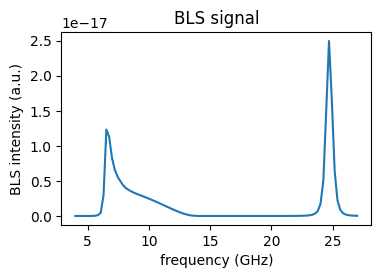

In [4]:
# Plot the BLS signal
plt.figure(figsize=(4, 2.5))
plt.plot(w_common/2/np.pi/1e9, sigma, label='Kalinikos-Slavin model')
plt.xlabel('frequency (GHz)')
plt.ylabel('BLS intensity (a.u.)')
plt.title('BLS signal')
plt.show()

*(Note: Sometimes the relative amplitude of PSSW peaks does not match the experiment, since it may depend on a vast number of parameters. If that is the case, calculate the BLS signal separately and normalize to each respective peak.)*

### Tip on speeding things up
Calculations of 2D dispersion and Bloch functions using some dispersion models can be greatly accelerated when we pass the `K` and `PHI` as flattened arrays. What happens is that if the model does not iterate over wavenumbers, it can calculate the dispersion for the whole 1D array of wavenumbers at once (therefore there is no need for the double for loop). If we supply a parameter of the same shape, it may be broadcasted together. The only thing we need to do then is to reshape the acquired data back to our square reciprocal space grid.

Unfortunately, this is currently supported only by the `SingleLayer` and `SingleLayerNumeric` classes. Maybe we will try to implement it in a limited form also in other classes. (The other BLS examples use this faster approach.)

For example this code from above

In [5]:
import time
from scipy.interpolate import interp1d

t0 = time.perf_counter()
# Preallocate the Bloch functions on the common frequency axis, shape (Nf_common, Nk, Nk).
Bloch2D = np.zeros((Nf_common, Nk, Nk))
# Create a SingleLayer model; kxi and phi are set for each grid point below.
model = SWT.SingleLayer(Bext=Bext, kxi=(0,), theta=theta,
                        phi=0, d=d_layer, material=material)
# Loop over all grid points in the Kx,Ky plane.
for i in range(Nk):
    for j in range(Nk):
        # Set correct kxi and phi for the current grid point.
        model.kxi = np.array((K[i, j],))  # must be an array
        model.phi = PHI[i, j]
        model.phi_H = PHI[i, j]  # set the correct phi_H for the current grid point
        for n in (0, 1):  # higher n are outside `w_common`
            # The returned w has shape (Nf_common,) and bf has shape (Nf_common, 1),
            # since we are passing kxi as length-1 array.
            # We pass also parameters for Bose-Einstein distribution (optional).
            w, bf = model.GetBlochFunction(n=n, Nf=Nf_common, temp=300, mu=-1e12*SWT.H)
            # Interpolate the Bloch function to the common frequency axis and add it.
            Bloch2D[:, i, j] += np.interp(w_common, w, bf[:, 0], left=0, right=0)
t_loop = time.perf_counter() - t0
print(f"Bloch functions calculated point by point in {t_loop:.1f} s")

Bloch functions calculated point by point in 17.1 s


can be replaced by this

In [6]:
t0 = time.perf_counter()
# Create a SingleLayer model for all grid points at once.
# Note: We pass kxi and phi as flattened arrays of same shape.
model = SWT.SingleLayer(Bext=Bext, kxi=K.flatten(), theta=theta,
                        phi=PHI.flatten(), d=d_layer, material=material)
Bloch2D_fast = np.zeros((Nf_common, Nk, Nk))
for n in (0, 1):
    # The returned w has shape (Nf,) and is common for all wavevectors, bf has shape
    # (Nf, Nk*Nk).  Since w now spans the frequencies of all wavevectors, more points
    # are needed to sample the narrow Bloch functions (here 10 times more).
    w, bf = model.GetBlochFunction(n=n, Nf=10*Nf_common, temp=300, mu=-1e12*SWT.H)
    # Interpolate to the common frequency axis (for all wavevectors at once)
    # and reshape to the Kx,Ky grid.
    bf = interp1d(w, bf, axis=0, bounds_error=False, fill_value=0)(w_common)
    Bloch2D_fast += bf.reshape((Nf_common, Nk, Nk))
t_fast = time.perf_counter() - t0
print(f"Bloch functions calculated for all wavevectors at once in {t_fast:.2f} s "
      f"({t_loop / t_fast:.0f}x faster)")
print(f"maximum difference: {np.abs(Bloch2D_fast - Bloch2D).max() / Bloch2D.max():.1%} of the maximum")

Bloch functions calculated for all wavevectors at once in 0.53 s (32x faster)
maximum difference: 2.3% of the maximum


which is much faster, especially for large grids.  The small differences come from the tails of the Bloch functions: `GetBlochFunction()` returns them only within about ±10 % around the frequencies of the given wavevectors, so the point-by-point calculation cuts the tails of each Bloch function (subject to change in the future), whereas here they span the frequency range of all wavevectors.